# 📊 Forex Market Analysis & Prediction with LSTMs

## Introduction  
In this notebook, we will explore a Forex market dataset, apply technical analysis, enrich the data with additional features, and conduct a thorough feature inspection. Our goal is to prepare the dataset for supervised learning and train a set of models, with a primary focus on **Long Short-Term Memory (LSTM) networks** for time-series forecasting. 

The key steps include:
1. **Exploratory Data Analysis (EDA)** – Understanding the structure of the dataset and key patterns.  
2. **Feature Inspection & Selection** – Identifying the most relevant variables for model training.  
3. **Data Preparation for Supervised Learning** – Transforming the dataset into an appropriate format for sequence-based models.  
4. **Model Training & Evaluation** – Implementing and assessing LSTMs along with other baseline models.  

This project aims to develop a robust **forecasting** framework for Forex trading.  

📌 **Author:** Lucas Pons  

In [1]:
# Import standard libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch  # For deep learning models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, accuracy_score, f1_score, confusion_matrix
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import warnings
import ipywidgets as widgets
from IPython.display import display

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Set global parameters
np.random.seed(42)
torch.manual_seed(42)
plt.style.use("seaborn-darkgrid")

print("Libraries successfully imported!")

Libraries successfully imported!


## 1️⃣ **Dataset Loading & Exploration (EDA)**  

### **Objective**
- Load Forex data from CSV files.
- Perform an initial exploration of the dataset.
- Visualize key features like price trends, volatility, and technical indicators.

In [2]:
# Directory containing the CSV files
data_dir = "/kaggle/input/pairs-technical-data/data"

# Dictionary to store the dataframes
forex_data_dict = {}

# Load each CSV file into the dictionary
for file in os.listdir(data_dir):
    if file.endswith(".csv"):
        file_path = os.path.join(data_dir, file)
        key_name = os.path.splitext(file)[0][-6:].upper()  # Remove .csv extension
        forex_data_dict[key_name] = pd.read_csv(file_path, parse_dates=["date"], index_col="date")

# Print confirmation
print(f"Loaded {len(forex_data_dict)} Forex datasets into the dictionary.")

Loaded 8 Forex datasets into the dictionary.


In [3]:
# Let's show the latest values of one of the dfs
df = forex_data_dict['AUDUSD']
df.tail()

,close,high,low,sma,ewma,upperband,lowerband,rsi,macd
date,,,,,,,,,
2025-01-29,0.625457,0.625700,0.621099,0.632251,0.651377,0.656119,0.608382,48.232639,-0.001019
2025-01-30,0.623978,0.624600,0.621580,0.631647,0.651104,0.654770,0.608524,45.943517,-0.001047
2025-01-31,0.621500,0.624350,0.620601,0.631049,0.650810,0.653627,0.608471,42.319647,-0.001255
2025-02-03,0.614420,0.619652,0.608900,0.630317,0.650448,0.652623,0.608011,34.055101,-0.001969
2025-02-04,0.620729,0.623577,0.617459,0.629652,0.650152,0.651041,0.608262,44.462315,-0.002002


In [4]:
df.shape, df.isnull().sum()

((4873, 9),
 close          0
 high           0
 low            0
 sma           49
 ewma         198
 upperband     49
 lowerband     49
 rsi           14
 macd           0
 dtype: int64)

#### Handling Missing Values

Our dataset contains missing values due to the calculation of technical indicators:  

- **SMA, Bollinger Bands** need a rolling window, causing initial NaNs.  
- **EWMA** has more missing values due to its longer lookback period.  
- **RSI** requires historical data to compute momentum, leading to NaNs in the first few rows.  

To ensure a clean dataset, we will **remove all rows with missing values** since they are, proportionally to the size of the dataframe, very few.

In [5]:
# Remove all rows with missing values
for df_name, df in forex_data_dict.items():
    df.dropna(inplace=True)
    print(f"Shape of {df_name} is: {df.shape}")

Shape of AUDUSD is: (4675, 9)
Shape of USDJPY is: (7133, 9)
Shape of EURUSD is: (5299, 9)
Shape of USDCNY is: (5701, 9)
Shape of EURGBP is: (6599, 9)
Shape of GBPUSD is: (5311, 9)
Shape of USDCHF is: (5365, 9)
Shape of USDCAD is: (5367, 9)


#### Exploring Key Features: Volatility, Price Trends, and Technical Indicators


To improve readability, we will focus on the four most important currency pairs: **EUR/USD, USD/JPY, EUR/GBP, AUD/USD and USD/CAD**. These pairs represent major market movements and provide meaningful insights without overcrowding the visualizations.

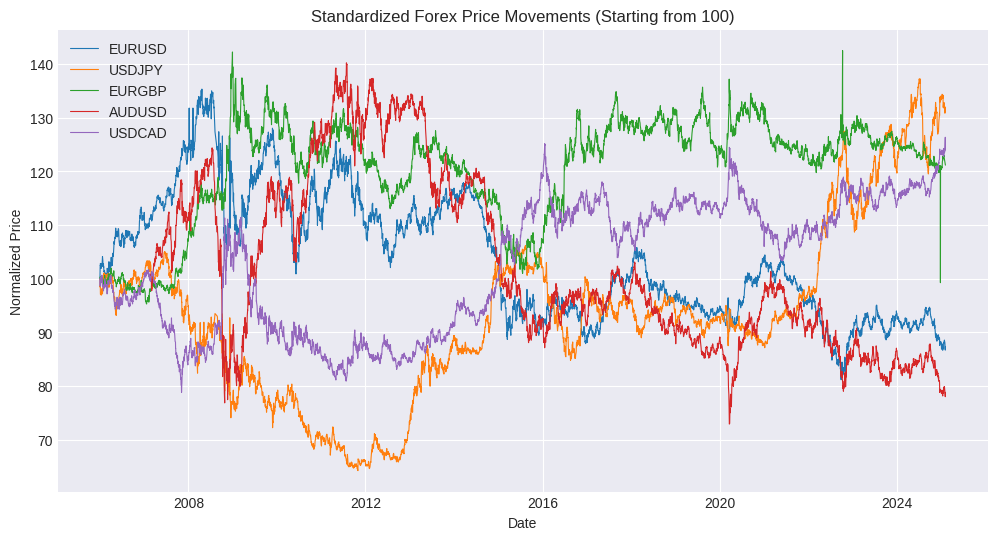

In [6]:
# Select the key currency pairs
selected_pairs = ["EURUSD", "USDJPY", "EURGBP", "AUDUSD", "USDCAD"]

# Define the reference start date
start_date = "2006-01-01"

plt.figure(figsize=(12, 6))

for name in selected_pairs:
    if name in forex_data_dict:
        df = forex_data_dict[name].copy()

        # Filter data from the chosen start date
        df = df[df.index >= start_date]

        # Normalize prices to start at 100
        df["Normalized Price"] = (df["close"] / df["close"].iloc[0]) * 100

        # Plot the normalized price movement
        plt.plot(df.index, df["Normalized Price"], label=name, lw=0.8)

# Labels and Titles
plt.title("Standardized Forex Price Movements (Starting from 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.show()

##### Observations on Standardized Forex Price Movements

The visualization provides a clear representation of how different currency pairs have evolved from a common starting point. While there might be some correlations between pairs, their movements suggest a degree of independence, reflecting distinct market dynamics for each currency.

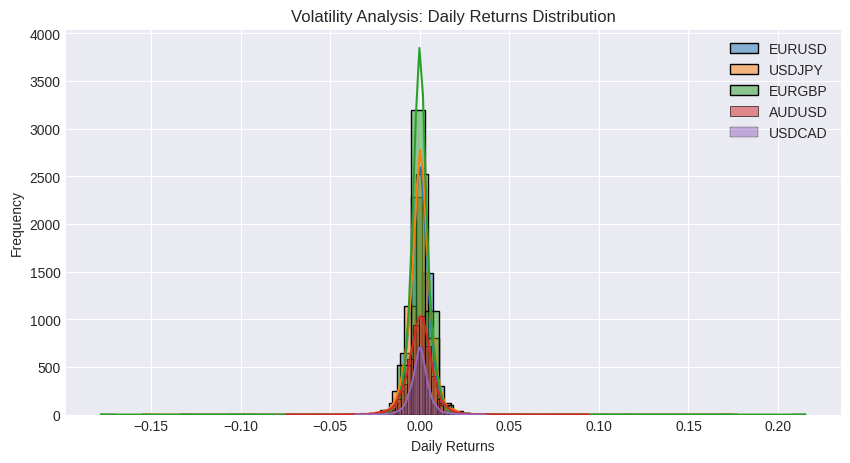

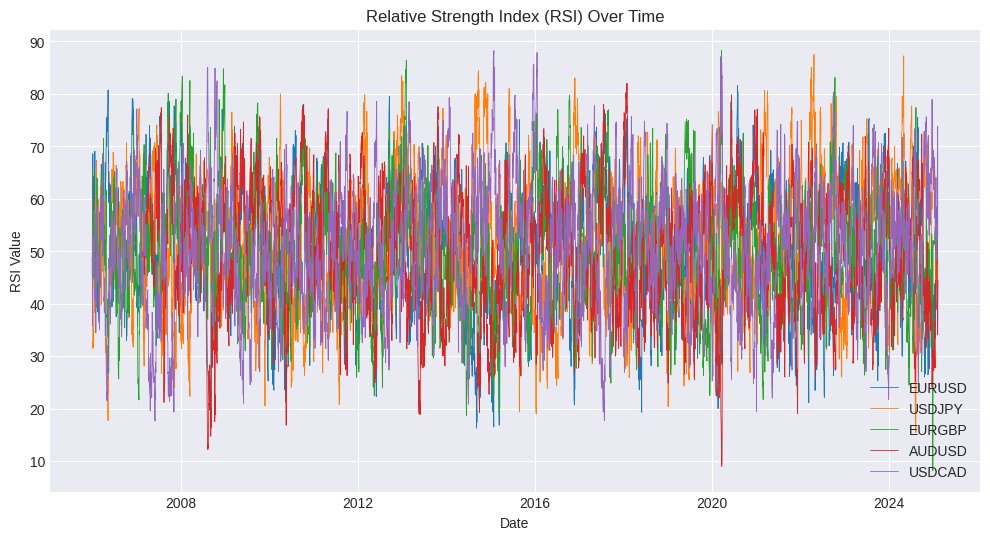

In [7]:
# Volatility Analysis: Daily Returns Distribution
plt.figure(figsize=(10, 5))

for name in selected_pairs:
    if name in forex_data_dict:
        df = forex_data_dict[name].copy()
        # Filter data from the chosen start date
        df = df[df.index >= start_date]
        df["Returns"] = df["close"].pct_change()
        sns.histplot(df["Returns"].dropna(), bins=50, kde=True, label=name, alpha=0.5)

plt.title("Volatility Analysis: Daily Returns Distribution")
plt.xlabel("Daily Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# RSI Plot Over Time
plt.figure(figsize=(12, 6))

for name in selected_pairs:
    if name in forex_data_dict:
        df = forex_data_dict[name].copy()
        # Filter data from the chosen start date
        df = df[df.index >= start_date]
        plt.plot(df.index, df["rsi"], label=name, lw=0.6)

plt.title("Relative Strength Index (RSI) Over Time")
plt.xlabel("Date")
plt.ylabel("RSI Value")
plt.legend()
plt.show()

##### Observations on Volatility and RSI  

The return distribution shows that some currency pairs have a **higher concentration around zero**, indicating lower volatility, while others have a **wider spread**, suggesting higher price fluctuations. This reflects differences in market stability and trading activity across pairs.  

The RSI plot does not provide a clear takeaway, as values fluctuate over time without a strong pattern across pairs.

---
## 2️⃣ **Data Transformation for LSTM Model**

To prepare the dataset for LSTM-based classification, we will:  
- Align all currency pairs to start from the same date.  
- Add periodicity features using sine and cosine transformations.  
- Create a target variable with three classes: **uptrend, downtrend, and stable**.  
- Check class balance for each pair.  
- Split the data into **train, validation, and test sets**.  
- Transform the data into a supervised learning format.  

#### Aligning All Pairs to the Same Start Date  

To ensure consistency, we will trim all datasets to begin at the earliest common date.

In [8]:
# Find the latest start date across all datasets
common_start_date = max(df.index.min() for df in forex_data_dict.values())

# Align all datasets to start from this date
for df in forex_data_dict.values():
    df = df[df.index >= common_start_date]

print(f"All datasets aligned to start from {common_start_date}.")

All datasets aligned to start from 2007-02-16 00:00:00.


#### Adding Periodicity Feature

To capture seasonal effects, we apply sine and cosine transformations on time.

In [9]:
def add_time_periodicity(df):
    df['Seconds'] = df.index.map(pd.Timestamp.timestamp)
    day = 60 * 60 * 24
    year = 365.2425 * day
    df['Year sin'] = np.sin(df['Seconds'] * (2 * np.pi / year))
    df['Year cos'] = np.cos(df['Seconds'] * (2 * np.pi / year))
    df.drop('Seconds', axis=1, inplace=True)
    return df

for df in forex_data_dict.values():
    df = add_time_periodicity(df)

print("Periodicity features added to all datasets.")

Periodicity features added to all datasets.


#### Creating the Target Variable  

The target variable will classify future price movements as:  
- **Downtrend (0):** Price decreases beyond an epsilon threshold.  
- **Stable (1):** Price movement remains within the threshold.
- **Uptrend (2):** Price increases beyond an epsilon threshold.

To determine whether the target variable should be stable or either uptrend or downtrend, we define an **epsilon**. However, instead of using a fixed threshold, **epsilon** will be dynamically set for each dataset based on its volatility. We define epsilon as a fraction of the standard deviation of daily returns to account for different levels of price fluctuations across currency pairs.

In [10]:
for name in forex_data_dict:
    df = forex_data_dict[name].copy()

    # Compute rolling volatility (standard deviation of returns)
    volatility = df["close"].pct_change().std()

    # Set epsilon as a fraction of volatility
    epsilon = 0.3 * volatility

    # Compute future returns
    df["Future Return"] = df["close"].pct_change().shift(-1)

    # Assign classification labels
    df["Target"] = np.where(df["Future Return"] > epsilon, 2,  # Uptrend
                  np.where(df["Future Return"] < -epsilon, 0, 1))  # Downtrend / Stable

    # Drop unnecessary column
    df.drop(columns=["Future Return", "close"], inplace=True)

    forex_data_dict[name] = df

    print(f"{name}: Epsilon set to {round(epsilon, 6)} based on volatility.")

print("Target variable updated using dynamic epsilon.")

AUDUSD: Epsilon set to 0.00239 based on volatility.
USDJPY: Epsilon set to 0.002191 based on volatility.
EURUSD: Epsilon set to 0.002117 based on volatility.
USDCNY: Epsilon set to 0.000882 based on volatility.
EURGBP: Epsilon set to 0.001918 based on volatility.
GBPUSD: Epsilon set to 0.001764 based on volatility.
USDCHF: Epsilon set to 0.00196 based on volatility.
USDCAD: Epsilon set to 0.001637 based on volatility.
Target variable updated using dynamic epsilon.


**Checking Class Balance**

To evaluate the distribution of uptrend, downtrend, and stable classes across datasets.

In [11]:
for name, df in forex_data_dict.items():
    print(f"\n{name} Target Distribution:")
    print(df["Target"].value_counts(normalize=True))


AUDUSD Target Distribution:
Target
2    0.354866
0    0.335829
1    0.309305
Name: proportion, dtype: float64

USDJPY Target Distribution:
Target
1    0.345437
2    0.339549
0    0.315015
Name: proportion, dtype: float64

EURUSD Target Distribution:
Target
1    0.361578
2    0.321004
0    0.317418
Name: proportion, dtype: float64

USDCNY Target Distribution:
Target
1    0.603929
0    0.209788
2    0.186283
Name: proportion, dtype: float64

EURGBP Target Distribution:
Target
1    0.369147
0    0.318230
2    0.312623
Name: proportion, dtype: float64

GBPUSD Target Distribution:
Target
2    0.356242
0    0.350217
1    0.293542
Name: proportion, dtype: float64

USDCHF Target Distribution:
Target
2    0.337931
1    0.335135
0    0.326934
Name: proportion, dtype: float64

USDCAD Target Distribution:
Target
2    0.341532
0    0.340973
1    0.317496
Name: proportion, dtype: float64


#### Splitting the Data  

We will split each dataset into **train, validation, and test sets**.

In [12]:
def split_data(data, test_size=0.1, val_size=0.1):
    train_idx = round(len(data) * (1 - test_size - val_size))
    val_idx = train_idx + round(len(data) * val_size)

    train = np.array(data[:train_idx])
    val = np.array(data[train_idx:val_idx])
    test = np.array(data[val_idx:])

    return train, val, test

split_data_dict = {}

for name, df in forex_data_dict.items():
    train, val, test = split_data(df)
    split_data_dict[name] = {"train": train, "val": val, "test": test}

print("Data successfully split into train, validation, and test sets.")

Data successfully split into train, validation, and test sets.


#### Transforming Data into Supervised Learning Format  

We convert sequential data into input-output pairs for LSTM training.

In [13]:
def df_to_X_y2(df, window_size=50):
    X, y = [], []
    for i in range(len(df) - window_size):
        row = df[i:i+window_size, :-1]
        X.append(row)
        label = df[i+window_size, -1]
        y.append(label)
    return np.array(X), np.array(y)

supervised_data_for_lstm = {}

for name, data in split_data_dict.items():
    train_X, train_y = df_to_X_y2(data["train"])
    val_X, val_y = df_to_X_y2(data["val"])
    test_X, test_y = df_to_X_y2(data["test"])
    
    supervised_data_for_lstm[name] = {
        "train_X": train_X, "train_y": train_y,
        "val_X": val_X, "val_y": val_y,
        "test_X": test_X, "test_y": test_y
    }

print("Data transformed into supervised learning format.")

Data transformed into supervised learning format.


In [14]:
# Remove all rows with missing values
for df_name, df in supervised_data_for_lstm.items():
    print(f"Shape of {df_name} is: {df['train_X'].shape}")

Shape of AUDUSD is: (3690, 50, 10)
Shape of USDJPY is: (5656, 50, 10)
Shape of EURUSD is: (4189, 50, 10)
Shape of USDCNY is: (4511, 50, 10)
Shape of EURGBP is: (5229, 50, 10)
Shape of GBPUSD is: (4199, 50, 10)
Shape of USDCHF is: (4242, 50, 10)
Shape of USDCAD is: (4244, 50, 10)


In [15]:
# Dictionary storing data for baseline models, without the need for sliding windows
supervised_data_for_baseline = split_data_dict

#### Data Transformation Complete!

The dataset is now aligned, periodicity features added, target variable created, and data split into train, validation, and test sets. The transformed dataset is ready for LSTM model training.

---
## 3️⃣ **Model Implementation and Baseline Comparisons**

We will implement and compare different models to predict forex price movements:  

- **Baseline Models**  
    - **Logistic Regression**: A basic statistical classifier.  
    - **Random Forest**: A robust ensemble method.  
    - **XGBoost**: A powerful gradient boosting algorithm.  


- **Deep Learning Model**  
  - **LSTM**: Captures sequential dependencies and long-term trends.  

We will train, evaluate, and compare the performance of these models across all datasets.  

#### Baseline Models: Logistic Regression, Random Forest, and XGBoost

We define traditional models for comparison before implementing LSTM.

In [16]:
def train_logistic_regression(train_X, train_y, test_X, test_y):
    model = LogisticRegression(max_iter=1000)
    model.fit(train_X, train_y)
    predictions = model.predict(test_X)
    acc = accuracy_score(test_y, predictions)
    f1 = f1_score(test_y, predictions, average='weighted')
    return model, acc, f1

def train_random_forest(train_X, train_y, test_X, test_y):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(train_X, train_y)
    predictions = model.predict(test_X)
    acc = accuracy_score(test_y, predictions)
    f1 = f1_score(test_y, predictions, average='weighted')
    return model, acc, f1

def train_xgboost(train_X, train_y, test_X, test_y):
    model = xgb.XGBClassifier(objective="multi:softmax", num_class=3, eval_metric="mlogloss")
    model.fit(train_X, train_y)
    predictions = model.predict(test_X)
    acc = accuracy_score(test_y, predictions)
    f1 = f1_score(test_y, predictions, average='weighted')
    return model, acc, f1

baseline_results = {}

for df_name, df in supervised_data_for_baseline.items():
    print(f"Training baseline models for {df_name}...", end=" ")
    train_df, test_df = df['train'], df['val']
    train_X, train_y = train_df[:, :-1], train_df[:, -1]
    test_X, test_y = test_df[:, :-1], test_df[:, -1]

    log_reg, log_reg_acc, log_reg_f1 = train_logistic_regression(train_X, train_y, test_X, test_y)
    rf_model, rf_acc, rf_f1 = train_random_forest(train_X, train_y, test_X, test_y)
    xgb_model, xgb_acc, xgb_f1 = train_xgboost(train_X, train_y, test_X, test_y)

    baseline_results[df_name] = {
        "Logistic Regression Accuracy": log_reg_acc,
        "Logistic Regression F1-Score": log_reg_f1,
        "Random Forest Accuracy": rf_acc,
        "Random Forest F1-Score": rf_f1,
        "XGBoost Accuracy": xgb_acc,
        "XGBoost F1-Score": xgb_f1
    }
    print("Success!")

print("Baseline classification models trained.")

Training baseline models for AUDUSD... Success!
Training baseline models for USDJPY... Success!
Training baseline models for EURUSD... Success!
Training baseline models for USDCNY... Success!
Training baseline models for EURGBP... Success!
Training baseline models for GBPUSD... Success!
Training baseline models for USDCHF... Success!
Training baseline models for USDCAD... Success!
Baseline classification models trained.


### <u>LSTM</u>  
#### Model Definition

We define the LSTM model using PyTorch to handle sequential data. It processes input time series through an LSTM layer, then outputs class logits via a fully connected layer. For our three-class problem (**up, down, stable**), we apply **CrossEntropyLoss()**, which aligns naturally with classification tasks. This setup preserves time dependencies and allows the model to learn meaningful patterns from historical price data. 

In [17]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=3):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True
        )
        # Final linear layer outputs 3 logits for our 3 classes
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # LSTM returns (batch_size, sequence_length, hidden_size)
        lstm_out, _ = self.lstm(x)
        
        # Take the hidden state at the last time step
        last_hidden = lstm_out[:, -1, :]
        
        # Output raw logits, no Tanh/Softmax here (CrossEntropyLoss does that internally)
        output = self.fc(last_hidden)
        
        return output

#### Training Function  

We define a function to train the LSTM model and track loss curves.

In [18]:
def train_lstm(model, train_loader, val_loader, num_epochs, learning_rate, device):
    model.to(device)  # Move the model to GPU (if available)
    
    # For multi-class classification, use CrossEntropyLoss
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for X_batch, y_batch in train_loader:
            # Ensure y_batch has shape (batch,) of integer class indices
            # e.g., y_batch in {0, 1, 2}
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()  # Make sure it's long/dtype=int64 for CrossEntropy
            
            optimizer.zero_grad()
            
            outputs = model(X_batch)           # shape = (batch_size, 3)
            loss = criterion(outputs, y_batch) # CrossEntropyLoss expects raw logits + integer labels
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device).long()
                
                outputs = model(X_val)
                loss = criterion(outputs, y_val)
                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Train Loss: {train_losses[-1]:.4f}, "
              f"Val Loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

### Training LSTM for All Currency Pairs  

We will train an **LSTM model for each currency pair** in a single execution, ensuring that all models are trained and saved efficiently.  

**Available Pairs:**  
- AUDUSD  
- USDJPY  
- EURUSD  
- USDCNY  
- EURGBP  
- GBPUSD  
- USDCHF  
- USDCAD  

To accelerate training, we will move the model and data to **GPU (if available)**. Each trained model will be saved for later evaluation and comparison.  

In [19]:
# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [20]:
lstm_results = {}

for pair_name, data in supervised_data_for_lstm.items():
    print(f"Training LSTM for {pair_name}...")

    try:
        data = data.copy()
        
        # Convert data to tensors
        train_X_tensor = torch.tensor(data["train_X"], dtype=torch.float32).to(device)
        train_y_tensor = torch.tensor(data["train_y"], dtype=torch.float32).to(device)
        val_X_tensor = torch.tensor(data["val_X"], dtype=torch.float32).to(device)
        val_y_tensor = torch.tensor(data["val_y"], dtype=torch.float32).to(device)

        # Create DataLoader objects
        train_dataset = TensorDataset(train_X_tensor, train_y_tensor)
        val_dataset = TensorDataset(val_X_tensor, val_y_tensor)

        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
        val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

        # Initialize model
        model = LSTMModel(input_size=train_X_tensor.shape[2], hidden_size=64, num_layers=2).to(device)

        # Train the model
        train_losses, val_losses = train_lstm(model, train_loader, val_loader, num_epochs=40, learning_rate=0.001, device=device)

        # Store results and download model
        lstm_results[pair_name] = {"Model": model, "Train Loss": train_losses, "Val Loss": val_losses}
        torch.save(model.state_dict(), f"{pair_name}_lstm_model.pth")

        print(f"LSTM training complete. Model saved as {pair_name}_lstm_model.pth")
        # Ensure GPU memory is freed after each pair
        del model
        torch.cuda.empty_cache()
    except Exception as e:  # Catch any error type and continue training other pairs
        print(f"Error occurred while training {pair_name}: {e}")

print("All LSTM models trained successfully.")

Training LSTM for AUDUSD...
Epoch 1/40, Train Loss: 1.0990, Val Loss: 1.1086
Epoch 2/40, Train Loss: 1.1001, Val Loss: 1.1037
Epoch 3/40, Train Loss: 1.0995, Val Loss: 1.0998
Epoch 4/40, Train Loss: 1.0988, Val Loss: 1.0974
Epoch 5/40, Train Loss: 1.0983, Val Loss: 1.0966
Epoch 6/40, Train Loss: 1.0980, Val Loss: 1.0961
Epoch 7/40, Train Loss: 1.0975, Val Loss: 1.0960
Epoch 8/40, Train Loss: 1.0970, Val Loss: 1.0967
Epoch 9/40, Train Loss: 1.0964, Val Loss: 1.0962
Epoch 10/40, Train Loss: 1.0961, Val Loss: 1.0976
Epoch 11/40, Train Loss: 1.0954, Val Loss: 1.0970
Epoch 12/40, Train Loss: 1.0966, Val Loss: 1.0964
Epoch 13/40, Train Loss: 1.0944, Val Loss: 1.0980
Epoch 14/40, Train Loss: 1.0940, Val Loss: 1.0987
Epoch 15/40, Train Loss: 1.0944, Val Loss: 1.0978
Epoch 16/40, Train Loss: 1.0938, Val Loss: 1.0973
Epoch 17/40, Train Loss: 1.0931, Val Loss: 1.0987
Epoch 18/40, Train Loss: 1.0944, Val Loss: 1.0979
Epoch 19/40, Train Loss: 1.0938, Val Loss: 1.0967
Epoch 20/40, Train Loss: 1.0941

### LSTM Training and Validation Loss Analysis  

We visualize the **training and validation loss curves** for each currency pair.  
This helps us assess the model's learning progress and detect issues such as:  
- **Overfitting** (training loss decreases while validation loss stays high).  
- **Underfitting** (both losses remain high).  
- **Stable Learning** (gradual decrease in both losses).  


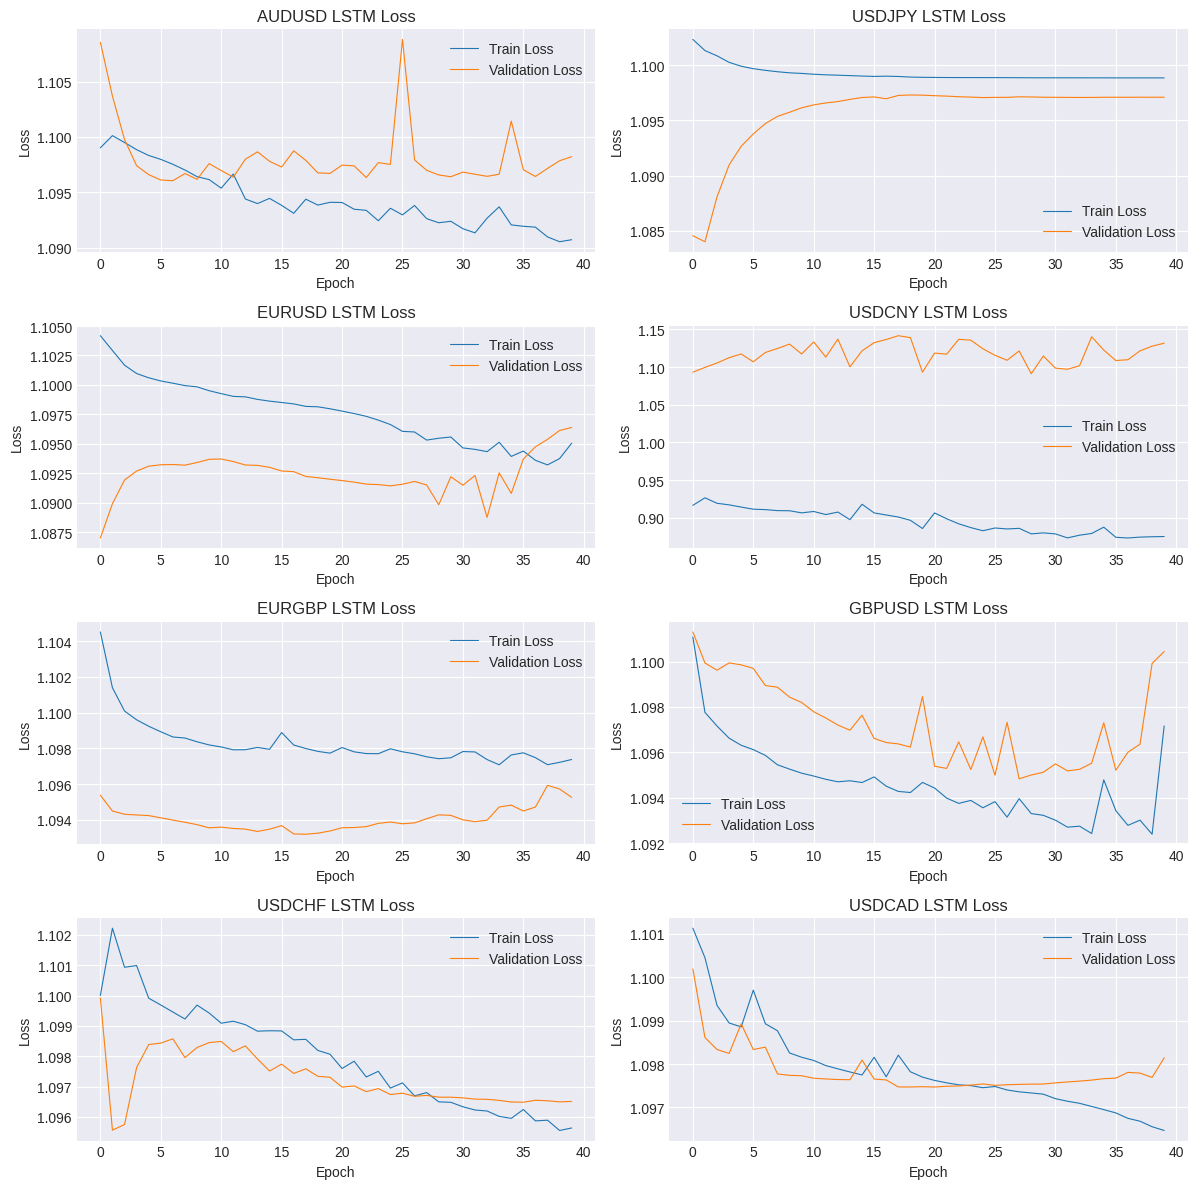

In [21]:
# Define the number of rows and columns for subplots
num_pairs = len(lstm_results)
cols = 2  # Two columns
rows = (num_pairs + 1) // cols  # Calculate required rows

fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
axes = axes.flatten()  # Flatten in case of odd number of pairs

for i, (name, result) in enumerate(lstm_results.items()):
    axes[i].plot(result["Train Loss"], label="Train Loss", lw=0.8)
    axes[i].plot(result["Val Loss"], label="Validation Loss", lw=0.8)
    axes[i].set_title(f"{name} LSTM Loss")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()

# Remove empty subplots if the number of pairs is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Conclusions on the LSTM Training Curves

The training curves generally behave as expected, showing a decreasing trend in both training and validation loss, indicating that the model is learning effectively. However, some currency pairs—**USDJPY, EURUSD, EURGBP, and USDCHF**—exhibit an unusual pattern where the validation loss remains very close to, or even lower than, the training loss.

While less common, this can occur when the validation dataset is easier to predict due to normal fluctuations in smaller datasets. This suggests that the model may be capturing patterns that generalize well to the validation set.

---
## 4️⃣ Model Performance Analysis & Hyperparameter Tuning  

We evaluate the LSTM model and compare it to baseline models using:  
- **Evaluation Metrics**: MSE, RMSE, and MAPE.  
- **Baseline Model Comparison**: Assess classification performance against logistic regression, random forest, and XGBoost.  
- **Residual and Error Distribution Analysis**: Identify model biases.  
- **Hyperparameter Tuning**: Optimize LSTM using GridSearchCV.  
- **Retraining**: Fine-tune LSTM with the best parameters.

<u>**Evaluation Metrics**</u>

We assess model performance using:  
- **Mean Squared Error (MSE)**: Measures squared differences between predicted and actual values.  
- **Root Mean Squared Error (RMSE)**: Square root of MSE for better interpretability.  
- **Mean Absolute Percentage Error (MAPE)**: Measures percentage deviation from actual values.  

In [22]:
def evaluate_model(y_true, y_pred):
    """
    Takes true labels and raw LSTM outputs (logits) as input.
    Converts logits to class predictions, then computes classification metrics.
    """
    # Convert model outputs to predicted class indices
    y_pred_class = np.argmax(model(test_X_tensor).cpu().detach().numpy(), axis=1)

    # Classification metrics
    accuracy = accuracy_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class, average='weighted')
    conf_matrix = confusion_matrix(y_true, y_pred_class)

    return accuracy, f1, conf_matrix

evaluation_results = {}

for name, data in supervised_data_for_lstm.items():
    model = lstm_results[name]["Model"]
    model.eval()

    with torch.no_grad():
        # Ensure tensor is on the same device as the model
        test_X_tensor = torch.tensor(data["test_X"], dtype=torch.float32).to(device)
        
        # Make predictions and move back to CPU before converting to numpy
        predictions = model(test_X_tensor).cpu().numpy()
        
    accuracy, f1, conf_matrix = evaluate_model(data["test_y"], predictions)
    evaluation_results[name] = {"Accuracy": accuracy, "F1-Score": f1, "Confusion Matrix": conf_matrix}

print("Model evaluation completed.")

Model evaluation completed.


#### Comparing LSTM to Baseline Models  

We compare the LSTM model's performance against traditional classifiers.

In [23]:
# Display comparison table for each currency pair
for name, results in baseline_results.items():
    print(f"\n{name} Model Comparison:")

    # Create a DataFrame for easy comparison
    comparison_df = pd.DataFrame({
        "Model": ["LSTM", "Logistic Regression", "Random Forest", "XGBoost"],
        "Accuracy": [
            evaluation_results[name]['Accuracy'],
            results["Logistic Regression Accuracy"],
            results["Random Forest Accuracy"],
            results["XGBoost Accuracy"]
        ],
        "F1-Score": [
            evaluation_results[name]['F1-Score'],  # LSTM F1-Score
            results["Logistic Regression F1-Score"],
            results["Random Forest F1-Score"],
            results["XGBoost F1-Score"]
        ]
    })

    print(comparison_df.to_string(index=False))
    print("---------------------------------------")


AUDUSD Model Comparison:
              Model  Accuracy  F1-Score
               LSTM  0.297362  0.149081
Logistic Regression  0.358974  0.189647
      Random Forest  0.363248  0.333629
            XGBoost  0.367521  0.357322
---------------------------------------

USDJPY Model Comparison:
              Model  Accuracy  F1-Score
               LSTM  0.376506  0.205966
Logistic Regression  0.551192  0.467356
      Random Forest  0.325386  0.323880
            XGBoost  0.312763  0.311494
---------------------------------------

EURUSD Model Comparison:
              Model  Accuracy  F1-Score
               LSTM  0.441667  0.323623
Logistic Regression  0.424528  0.300384
      Random Forest  0.358491  0.335995
            XGBoost  0.360377  0.354852
---------------------------------------

USDCNY Model Comparison:
              Model  Accuracy  F1-Score
               LSTM  0.444231  0.273282
Logistic Regression  0.450877  0.407365
      Random Forest  0.349123  0.350964
            XGBo

### Conclusion on results

Overall, the **LSTM** underperforms compared to the ensemble methods on most currency pairs. The traditional machine learning models—particularly **Random Forest** and **XGBoost**—often achieve higher accuracy and F1-scores, suggesting that either (1) the sequence patterns aren’t captured effectively by the LSTM with current hyperparameters or (2) the data preprocessing and feature engineering steps favor ensemble methods. These results highlight the importance of model selection, hyperparameter tuning, and potentially more sophisticated feature engineering when applying deep learning to forex data. Future work should focus on deeper hyperparameter searches for the LSTM and possibly adding domain-specific features to leverage its sequential modeling capabilities.

---
## 5️⃣ Strategy-development process

Even with accuracies below 40%, a model can still be profitable if combined with well-structured trading rules and risk management. Future work could involve deeper hyperparameter tuning and re-training, but our primary focus will be on **designing trading strategies** that leverage these signals effectively. We will explore stop-loss settings, position sizing, and entry-exit rules to maximize risk-adjusted returns, demonstrating how a modestly accurate prediction model can still yield profitable outcomes in the forex market.

### Strategy Simulation: Explanation of Code Cells

This code performs a complete backtest of a forex trading strategy using LSTM-generated signals. It begins by loading the EURUSD price dataset, ensuring that necessary columns exist. If the "high" and "low" price columns are missing, the ATR is approximated using the rolling standard deviation of closing prices.

Next, the pre-trained LSTM model is loaded, and test data is processed. The model generates predictions, which are converted into trading signals: 1 for Buy, -1 for Sell, and 0 for Hold.

The strategy is then applied by initializing the `AdvancedTradingStrategy` class, which uses dynamic position sizing and ATR-based stop-loss and take-profit levels. The backtest is run on historical data, recording executed trades in a structured DataFrame.

Finally, the script evaluates the strategy's performance by computing the final balance and total profit and loss. If no trades were executed, a message is displayed. The results are visualized with a cumulative profit and loss plot, helping to assess the strategy’s effectiveness.

In [24]:
class AdvancedTradingStrategy:
    """
    Implements an advanced risk management strategy based on LSTM signals.
    This includes position sizing based on volatility, dynamic stop-loss, and take-profit rules.
    """

    def __init__(self, initial_balance=10000, risk_per_trade=0.02, atr_multiplier=1.5):
        """
        Initializes the strategy parameters.
        
        Args:
            initial_balance (float): Starting capital for the strategy.
            risk_per_trade (float): Fraction of capital risked per trade (e.g., 2%).
            atr_multiplier (float): Multiplier for determining stop-loss distance.
        """
        self.balance = initial_balance
        self.risk_per_trade = risk_per_trade
        self.atr_multiplier = atr_multiplier
        self.position = 0
        self.entry_price = None
        self.stop_loss = None
        self.take_profit = None
        self.trade_history = []

    def calculate_atr(self, df, period=14):
        """
        Computes the Average True Range (ATR) for volatility-based stop-loss calculation.
        
        Args:
            df (pd.DataFrame): Market data containing 'high', 'low', and 'close' prices.
            period (int): Lookback period for ATR calculation.
        
        Returns:
            pd.Series: ATR values.
        """
        high_low = df['high'] - df['low']
        high_close = np.abs(df['high'] - df['close'].shift())
        low_close = np.abs(df['low'] - df['close'].shift())

        tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        atr = tr.rolling(window=period).mean()

        return atr

    def calculate_position_size(self, atr, price):
        """
        Determines position size dynamically based on volatility.
        
        Args:
            atr (float): Current ATR value.
            price (float): Current market price.
        
        Returns:
            int: Number of units to trade.
        """
        risk_amount = self.balance * self.risk_per_trade
        stop_loss_distance = atr * self.atr_multiplier
        position_size = risk_amount / stop_loss_distance

        return int(position_size)

    def execute_trade(self, signal, price, atr):
        """
        Executes trades based on model signals, setting dynamic stop-loss and take-profit.
        
        Args:
            signal (int): Model output (-1: Sell, 0: No Trade, 1: Buy).
            price (float): Current market price.
            atr (float): Current ATR value.
        """
        if signal == 1 and self.position == 0:  # Open Long Trade
            position_size = self.calculate_position_size(atr, price)
            self.position = position_size
            self.entry_price = price
            self.stop_loss = price - (atr * self.atr_multiplier)
            self.take_profit = price + (atr * self.atr_multiplier * 2)  # 2:1 Risk-Reward
            self.trade_history.append(('BUY', price, self.stop_loss, self.take_profit, position_size))

        elif signal == -1 and self.position == 0:  # Open Short Trade
            position_size = self.calculate_position_size(atr, price)
            self.position = -position_size
            self.entry_price = price
            self.stop_loss = price + (atr * self.atr_multiplier)
            self.take_profit = price - (atr * self.atr_multiplier * 2)  # 2:1 Risk-Reward
            self.trade_history.append(('SELL', price, self.stop_loss, self.take_profit, position_size))

    def manage_trade(self, price):
        """
        Checks stop-loss and take-profit conditions to close trades dynamically.
        
        Args:
            price (float): Current market price.
        """
        if self.position > 0:  # Managing a long trade
            if price <= self.stop_loss:  # Stop-loss hit
                self.balance -= self.risk_per_trade * self.balance
                self.position = 0
            elif price >= self.take_profit:  # Take-profit hit
                self.balance += self.risk_per_trade * self.balance * 2  # 2:1 reward
                self.position = 0

        elif self.position < 0:  # Managing a short trade
            if price >= self.stop_loss:  # Stop-loss hit
                self.balance -= self.risk_per_trade * self.balance
                self.position = 0
            elif price <= self.take_profit:  # Take-profit hit
                self.balance += self.risk_per_trade * self.balance * 2  # 2:1 reward
                self.position = 0

    def backtest(self, df):
        """
        Backtests the strategy on historical data.
        
        Args:
            df (pd.DataFrame): Market data with 'close' prices and model 'signal' predictions.
        """
        df['ATR'] = self.calculate_atr(df)

        for index, row in df.iterrows():
            signal = row['signal']
            price = row['close']
            atr = row['ATR']

            if pd.notna(atr):
                self.execute_trade(signal, price, atr)
                self.manage_trade(price)

        print(f"Final Balance: ${self.balance:.2f}")
        return self.trade_history

Final Balance: $10739.39
  Type  EntryPrice  StopLoss  TakeProfit  PositionSize
0  BUY     1.34808  1.336710    1.370820         17590
1  BUY     1.33368  1.320504    1.360033         14875
2  BUY     1.32095  1.307084    1.348683         13852
3  BUY     1.35366  1.341421    1.378138         16322
4  BUY     1.38140  1.369019    1.406163         16779

Final Balance: $10739.39
Total Profit & Loss: $739.39


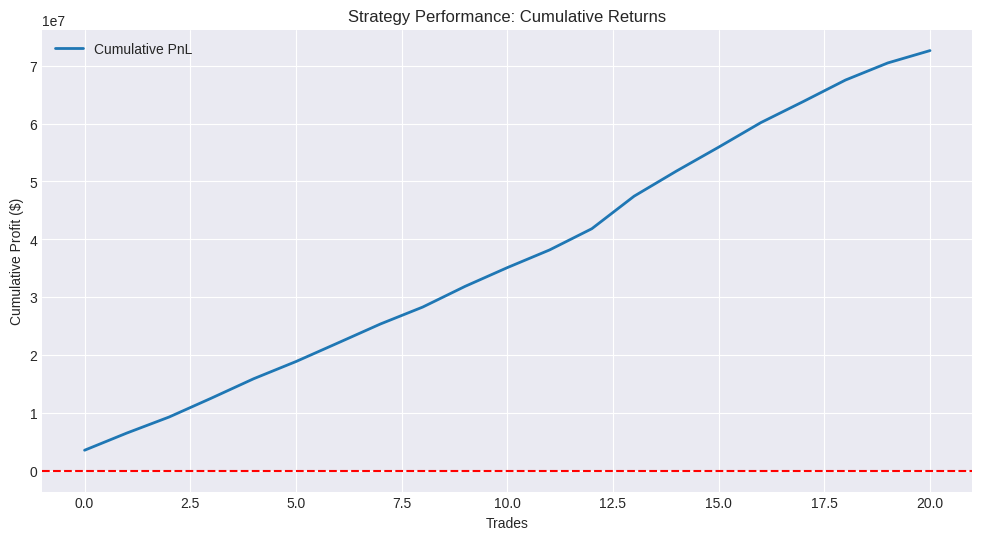

In [25]:
# Example test of strategy on one currency pair (e.g. "EURUSD")

# Loading forex price data
data_dir = "/kaggle/input/pairs-technical-data/data/pairs_technical_eurusd.csv"
forex_data = pd.read_csv(file_path, parse_dates=["date"], index_col="date")
price_data_eurusd = forex_data[forex_data.index >= '2007-02-16'][['close', 'high', 'low']]

# Set device to CPU
device = torch.device("cpu")

# Load test data
X_test = supervised_data_for_lstm["EURUSD"]["test_X"]

# Load trained LSTM model
model = LSTMModel(input_size=X_test.shape[2], hidden_size=64, num_layers=2).to(device)
model.load_state_dict(torch.load("/kaggle/working/EURUSD_lstm_model.pth"))
model.eval()

# Generate predictions
with torch.no_grad():
    y_pred = model(torch.tensor(X_test, dtype=torch.float32).to(device))
    y_pred = torch.argmax(y_pred, dim=1).cpu().numpy()  # Convert to class labels

# Convert predictions into trading signals: 1 (Buy), -1 (Sell), 0 (Hold)
price_data_eurusd = price_data_eurusd.iloc[-len(y_pred):]  # Match test data length
price_data_eurusd["signal"] = np.where(y_pred == 1, 1, np.where(y_pred == 2, -1, 0))

# Initialize the trading strategy
strategy = AdvancedTradingStrategy(initial_balance=10000, risk_per_trade=0.02, atr_multiplier=1.5)

# Backtest the strategy on the dataset
trades = strategy.backtest(price_data_eurusd)

# Convert trades to DataFrame for visualization
trades_df = pd.DataFrame(trades, columns=["Type", "EntryPrice", "StopLoss", "TakeProfit", "PositionSize"])

# Compute final balance
final_balance = strategy.balance
start_balance = 10000.0
total_pnl = final_balance - start_balance

# Print results
if not trades_df.empty:
    print(trades_df.head())
    print(f"\nFinal Balance: ${final_balance:.2f}")
    print(f"Total Profit & Loss: ${total_pnl:.2f}")
else:
    print("No trades were executed. The model may have predicted 'Hold' for all instances.")

# Plot cumulative returns
plt.figure(figsize=(12, 6))
cumulative_returns = (trades_df["PositionSize"].cumsum() * 0.02 * start_balance).fillna(0)  # Estimate profit/loss
plt.plot(cumulative_returns, label="Cumulative PnL", linewidth=2)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Trades")
plt.ylabel("Cumulative Profit ($)")
plt.title("Strategy Performance: Cumulative Returns")
plt.legend()
plt.show()